
Input data
  Quantified cold sites n = 5
  Sites: Micciano, Libbiano, Palazzo al Piano, Montemiccioli, Occhibolleri
  Cold-site outputs = 1.00-18.60 t/d
  Arithmetic mean = 5.61 t/d
  Threshold range = 10-1000 t/d
  Threshold grid = 300 values
  Probability field alpha = 0.7
  Plotting-only smoothing: sigma_threshold = 3.0, sigma_n = 2.0
  Running contour analysis: 210 N values x 30000 iterations

Threshold summary from original unsmoothed Monte Carlo grid:
  > 50 t/d
    50% probability at N = 11
    95% probability at N = 23
  > 100 t/d
    50% probability at N = 19
    95% probability at N = 44
  > 200 t/d
    50% probability at N = 38
    95% probability at N = 86
  > 300 t/d
    50% probability at N = 55
    95% probability at N = 126
  > 400 t/d
    50% probability at N = 73
    95% probability at N = 168
  > 500 t/d
    50% probability at N = 91
    95% probability at N = 207
  > 1000 t/d
    50% probability at N = 177
    95% probability at N = not reached
  Saved: figures/Fig

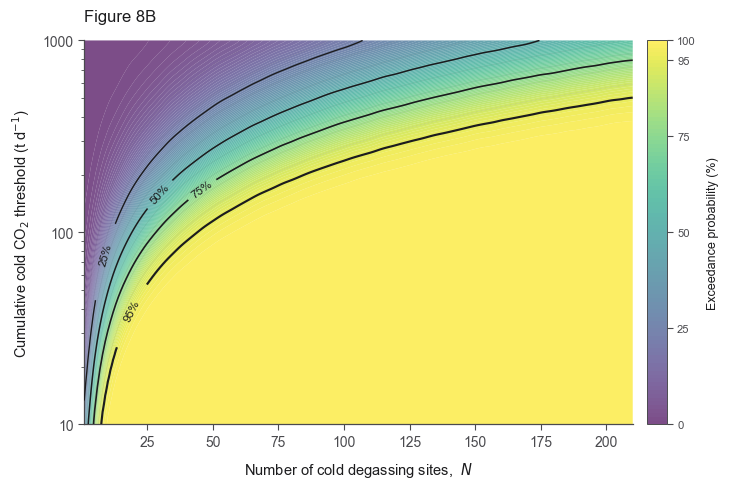

In [1]:
""" Figure 8B. Exceedance-probability contours for cumulative cold CO2 output.

Author: A. Rielli, Institute of Geosciece, National Research Council of Italy

The script computes, for each number of cold-degassing sites N, the probability that cumulative cold CO2 output exceeds a set of regional-output thresholds.
Input data are the five quantified cold-degassing localities used in Figure 8A: Micciano, Montemiccioli, Libbiano and Palazzo al Piano after Taussi et al. (2023), and Occhibolleri from this study.

Probabilities are calculated using the Dirichlet-weighted parametric bootstrap. The probability grid is smoothed only for plotting; printed summaries are based on the original unsmoothed Monte Carlo grid.
"""

from __future__ import annotations

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RNG_SEED = 42

# Increase to 50000 if you want slightly smoother Monte Carlo probabilities.
# 30000 is a good compromise between stability and runtime.
N_ITER = 30000

# Use 164 for the manuscript inventory.
# Use 210 only for exploratory plots beyond the current inventory.
N_MAX = 210
N_ALL = np.arange(1, N_MAX + 1)

OUTPUT_DIR = "figures"
PNG_DPI = 600

# Threshold range in t d-1.
# Use 500 for a more focused main-text figure.
# Use 1000 for a broader plot.
THRESHOLD_MIN = 10.0
THRESHOLD_MAX = 1000.0
N_THRESHOLDS = 300

THRESHOLDS = np.geomspace(
    THRESHOLD_MIN,
    THRESHOLD_MAX,
    N_THRESHOLDS,
)

# Intermediate probability contour levels.
# These are light guide lines and are not labelled.
MINOR_CONTOUR_LEVELS = [10, 20, 30, 40, 60, 70, 80, 90]

# Main labelled contours.
MAIN_CONTOUR_LEVELS = [25, 50, 75]

# 95% is plotted separately to ensure it remains clearly visible.
HIGH_CONTOUR_LEVEL = [95]

# Smoothing parameters for plotting only.
# Larger values make the contour lines smoother.
# The original probability grid is still used for printed summaries.
SMOOTH_SIGMA_THRESHOLD = 3.0
SMOOTH_SIGMA_N = 2.0

# Heatmap transparency.
# 1.00 = opaque; 0.70 = moderately transparent.
FIELD_ALPHA = 0.70


# ---------------------------------------------------------------------------
# Input data in t/d
# ---------------------------------------------------------------------------

COLD_SITES = {
    "Micciano": 1.0,
    "Libbiano": 1.2,
    "Palazzo al Piano": 3.2,
    "Montemiccioli": 18.6,
    "Occhibolleri": 4.04,
}


# ---------------------------------------------------------------------------
# Design system
# ---------------------------------------------------------------------------

INK = "#1C1C1E"
INK_SOFT = "#4A4A4E"
PAPER = "#FFFFFF"

# Illustrator-safe font stack.
FONT_STACK = ["Arial", "Helvetica", "DejaVu Sans"]

# Viridis colour scale:
# low probability = blue/purple; high probability = yellow.
CMAP = plt.get_cmap("viridis")


# ---------------------------------------------------------------------------
# Monte Carlo functions
# ---------------------------------------------------------------------------

def sample_totals_dirichlet_weighted(
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Dirichlet-weighted parametric bootstrap.

    For each Monte Carlo realisation:
    1. draw continuous Dirichlet weights over the observed cold-site outputs;
    2. compute weighted lognormal parameters in log-space;
    3. draw N synthetic site outputs from that weighted lognormal;
    4. sum them.
    """
    log_cold = np.log(cold)
    n_sites = cold.size

    weights = rng.dirichlet(
        alpha=np.ones(n_sites),
        size=n_iter,
    )

    mu_iter = (weights * log_cold[None, :]).sum(axis=1)

    diffs = log_cold[None, :] - mu_iter[:, None]
    weighted_var = (weights * diffs**2).sum(axis=1)

    # Effective-sample-size correction, weighted analogue of ddof = 1.
    correction = 1.0 / (1.0 - np.sum(weights**2, axis=1))
    sigma_iter = np.sqrt(weighted_var * correction)

    draws = rng.lognormal(
        mean=mu_iter[:, None],
        sigma=sigma_iter[:, None],
        size=(n_iter, N),
    )

    return draws.sum(axis=1)


def compute_probability_grid(
    cold: np.ndarray,
    thresholds: np.ndarray,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Compute exceedance probability for each threshold and each N.

    Returns:
        probability_grid:
            shape = (n_thresholds, n_N)
            values = exceedance probability in %
    """
    probability_grid = np.empty(
        (thresholds.size, N_ALL.size),
        dtype=float,
    )

    for j, N in enumerate(N_ALL):
        totals = sample_totals_dirichlet_weighted(
            cold=cold,
            N=int(N),
            n_iter=n_iter,
            rng=rng,
        )

        probability_grid[:, j] = (
            np.mean(totals[None, :] > thresholds[:, None], axis=1) * 100.0
        )

    return probability_grid


def smooth_probability_grid(
    grid: np.ndarray,
    sigma_threshold: float = 3.0,
    sigma_n: float = 2.0,
) -> np.ndarray:
    """
    Smooth the probability grid for plotting only using a separable
    Gaussian-like kernel.

    The original Monte Carlo probability grid is not modified and remains
    the basis for printed threshold summaries.
    """

    def gaussian_kernel1d(sigma: float) -> np.ndarray:
        """Build a normalised 1D Gaussian-like kernel."""
        if sigma <= 0:
            return np.array([1.0])

        radius = int(np.ceil(3 * sigma))
        x = np.arange(-radius, radius + 1)

        kernel = np.exp(-(x**2) / (2 * sigma**2))
        kernel /= kernel.sum()

        return kernel

    def convolve_along_axis(
        array: np.ndarray,
        kernel: np.ndarray,
        axis: int,
    ) -> np.ndarray:
        """Convolve an array along one axis using edge padding."""
        pad = len(kernel) // 2

        pad_width = [(0, 0)] * array.ndim
        pad_width[axis] = (pad, pad)

        padded = np.pad(
            array,
            pad_width=pad_width,
            mode="edge",
        )

        return np.apply_along_axis(
            lambda m: np.convolve(m, kernel, mode="valid"),
            axis=axis,
            arr=padded,
        )

    smoothed = grid.copy()

    kernel_threshold = gaussian_kernel1d(sigma_threshold)
    kernel_n = gaussian_kernel1d(sigma_n)

    smoothed = convolve_along_axis(
        smoothed,
        kernel_threshold,
        axis=0,
    )

    smoothed = convolve_along_axis(
        smoothed,
        kernel_n,
        axis=1,
    )

    return np.clip(smoothed, 0.0, 100.0)


# ---------------------------------------------------------------------------
# Plotting functions
# ---------------------------------------------------------------------------

def set_plot_style() -> None:
    """Set clean white-background Matplotlib style."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": FONT_STACK,
        "font.size": 10,
        "text.color": INK,
        "axes.edgecolor": INK_SOFT,
        "axes.labelcolor": INK,
        "axes.linewidth": 0.9,
        "axes.facecolor": PAPER,
        "figure.facecolor": PAPER,
        "savefig.facecolor": PAPER,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "ytick.minor.size": 2.2,
        "axes.axisbelow": True,

        # Keep text editable in Illustrator.
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def save_figure(fig: plt.Figure, filename_base: str) -> None:
    """
    Save figure in vector and raster formats.

    EPS is intentionally omitted because PostScript does not support
    transparency properly.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    pdf_path = os.path.join(OUTPUT_DIR, f"{filename_base}.pdf")
    svg_path = os.path.join(OUTPUT_DIR, f"{filename_base}.svg")
    png_path = os.path.join(OUTPUT_DIR, f"{filename_base}.png")
    tiff_path = os.path.join(OUTPUT_DIR, f"{filename_base}.tiff")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight")
    fig.savefig(tiff_path, dpi=PNG_DPI, bbox_inches="tight")

    print(f"  Saved: {pdf_path}")
    print(f"  Saved: {svg_path}")
    print(f"  Saved: {png_path}")
    print(f"  Saved: {tiff_path}")


def format_log_axis(ax: plt.Axes) -> None:
    """Format y-axis for log-scaled CO2 thresholds."""
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(mticker.LogLocator(base=10))

    ax.yaxis.set_minor_locator(
        mticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
        )
    )

    # Show 1000, not 1k.
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda value, _: f"{value:.0f}"
        )
    )


def make_probability_contour_figure(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
    save: bool = False,
) -> None:
    """
    Figure 8B:
    Exceedance-probability contour plot with smoothed contours for plotting.
    """
    set_plot_style()

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    N_grid, threshold_grid = np.meshgrid(N_ALL, thresholds)

    # -----------------------------------------------------------------------
    # Smooth probability field for plotting only.
    # Numerical threshold summaries use the original unsmoothed grid.
    # -----------------------------------------------------------------------
    probability_grid_plot = smooth_probability_grid(
        probability_grid,
        sigma_threshold=SMOOTH_SIGMA_THRESHOLD,
        sigma_n=SMOOTH_SIGMA_N,
    )

    # -----------------------------------------------------------------------
    # Semi-transparent Viridis probability field.
    # -----------------------------------------------------------------------
    background = ax.contourf(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=np.linspace(0, 100, 101),
        cmap=CMAP,
        alpha=FIELD_ALPHA,
        antialiased=True,
        zorder=1,
    )

    # -----------------------------------------------------------------------
    # Intermediate probability contours.
    # Light guide lines, without labels.
    # -----------------------------------------------------------------------
    ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=MINOR_CONTOUR_LEVELS,
        colors=INK,
        linewidths=0.30,
        alpha=0.13,
        zorder=3,
    )

    # -----------------------------------------------------------------------
    # Main labelled probability contours: 25, 50, 75%.
    # -----------------------------------------------------------------------
    main_contours = ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=MAIN_CONTOUR_LEVELS,
        colors=INK,
        linewidths=[1.00, 1.10, 1.20],
        zorder=4,
    )

    labels_main = ax.clabel(
        main_contours,
        fmt={25: "25%", 50: "50%", 75: "75%"},
        fontsize=8.4,
        colors=INK,
        inline=True,
        inline_spacing=5,
        rightside_up=True,
        use_clabeltext=True,
    )

    # -----------------------------------------------------------------------
    # 95% contour plotted separately.
    # This avoids the 95% line appearing thinner because it is shorter and
    # more strongly interrupted by the inline label.
    # -----------------------------------------------------------------------
    contour_95 = ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=HIGH_CONTOUR_LEVEL,
        colors=INK,
        linewidths=1.55,
        zorder=5,
    )

    labels_95 = ax.clabel(
        contour_95,
        fmt={95: "95%"},
        fontsize=8.4,
        colors=INK,
        inline=True,
        inline_spacing=5,
        rightside_up=True,
        use_clabeltext=True,
    )

    for label in list(labels_main) + list(labels_95):
        label.set_color(INK)
        label.set_fontsize(8.4)
        label.set_rotation_mode("anchor")

    # -----------------------------------------------------------------------
    # Axes.
    # -----------------------------------------------------------------------
    ax.set_xlim(1, N_MAX)
    ax.set_ylim(THRESHOLD_MIN, THRESHOLD_MAX)

    format_log_axis(ax)

    ax.set_xlabel(
        "Number of cold degassing sites,  $N$",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_ylabel(
        "Cumulative cold CO$_2$ threshold (t d$^{-1}$)",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_title("Figure 8B",
        fontsize=12,
        fontweight="medium",
        color=INK,
        pad=14,
        loc="left",

    )
      
    
    # -----------------------------------------------------------------------
    # Colourbar.
    # -----------------------------------------------------------------------
    cbar = fig.colorbar(
        background,
        ax=ax,
        pad=0.025,
        fraction=0.045,
    )

    cbar.set_label(
        "Exceedance probability (%)",
        fontsize=9,
        color=INK,
        labelpad=8,
    )

    cbar.set_ticks([0, 25, 50, 75, 95, 100])

    cbar.ax.tick_params(
        labelsize=8,
        colors=INK_SOFT,
    )

    cbar.outline.set_edgecolor(INK_SOFT)
    cbar.outline.set_linewidth(0.7)

    # -----------------------------------------------------------------------
    # Spines.
    # -----------------------------------------------------------------------
    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)

    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(INK_SOFT)
        ax.spines[spine_name].set_linewidth(0.9)

    ax.grid(False)

    fig.tight_layout()

    if save:
        save_figure(
            fig,
            "Figure_8B_probability_contours_viridis_25_50_75_95_clean",
        )

    plt.show()


# ---------------------------------------------------------------------------
# Console summaries
# ---------------------------------------------------------------------------

def first_n_reaching_probability(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
    target_threshold: float,
    target_probability: float,
) -> int | None:
    """
    Return first N at which the probability of exceeding target_threshold
    reaches target_probability.
    """
    idx_threshold = int(np.argmin(np.abs(thresholds - target_threshold)))
    probs = probability_grid[idx_threshold, :]

    idx_n = np.flatnonzero(probs >= target_probability)

    return int(idx_n[0]) + 1 if idx_n.size else None


def print_threshold_summary(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
) -> None:
    """Print useful threshold summaries from the original unsmoothed grid."""
    target_thresholds = [50, 100, 200, 300, 400, 500, 1000]

    print("\nThreshold summary from original unsmoothed Monte Carlo grid:")

    for threshold in target_thresholds:
        if threshold < thresholds.min() or threshold > thresholds.max():
            continue

        n50 = first_n_reaching_probability(
            probability_grid=probability_grid,
            thresholds=thresholds,
            target_threshold=threshold,
            target_probability=50,
        )

        n95 = first_n_reaching_probability(
            probability_grid=probability_grid,
            thresholds=thresholds,
            target_threshold=threshold,
            target_probability=95,
        )

        n50_text = "not reached" if n50 is None else str(n50)
        n95_text = "not reached" if n95 is None else str(n95)

        print(f"  > {threshold:g} t/d")
        print(f"    50% probability at N = {n50_text}")
        print(f"    95% probability at N = {n95_text}")


# ---------------------------------------------------------------------------
# Run Figure 8B
# ---------------------------------------------------------------------------

def main() -> None:
    rng = np.random.default_rng(RNG_SEED + 2024)
    cold = np.array(list(COLD_SITES.values()), dtype=float)

    print("\nInput data")
    print(f"  Quantified cold sites n = {cold.size}")
    print(f"  Sites: {', '.join(COLD_SITES.keys())}")
    print(f"  Cold-site outputs = {cold.min():.2f}-{cold.max():.2f} t/d")
    print(f"  Arithmetic mean = {cold.mean():.2f} t/d")
    print(f"  Threshold range = {THRESHOLD_MIN:g}-{THRESHOLD_MAX:g} t/d")
    print(f"  Threshold grid = {N_THRESHOLDS} values")
    print(f"  Probability field alpha = {FIELD_ALPHA}")
    print(
        "  Plotting-only smoothing: "
        f"sigma_threshold = {SMOOTH_SIGMA_THRESHOLD}, "
        f"sigma_n = {SMOOTH_SIGMA_N}"
    )
    print(f"  Running contour analysis: {N_MAX} N values x {N_ITER} iterations")

    probability_grid = compute_probability_grid(
        cold=cold,
        thresholds=THRESHOLDS,
        n_iter=N_ITER,
        rng=rng,
    )

    print_threshold_summary(
        probability_grid=probability_grid,
        thresholds=THRESHOLDS,
    )

    make_probability_contour_figure(
        probability_grid=probability_grid,
        thresholds=THRESHOLDS,
        save=True,
    )


if __name__ == "__main__":
    main()